### Chapter 6 - Heuristic and Samplings

In [164]:
import networkx as nx
import random as rd
import numpy as np
import math
import matplotlib.pyplot as plt
import copy

Creating an graph of 5 nodes as an initial example

In [87]:
n = 10
p = 5/(n - 1)
G1 = nx.erdos_renyi_graph(n, p)

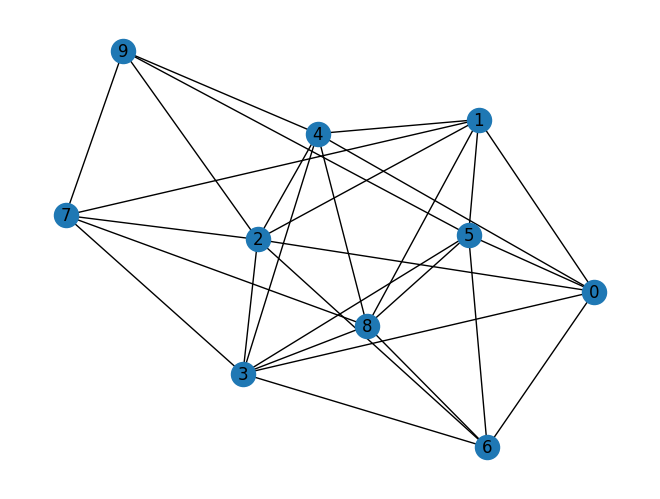

In [88]:
nx.draw(G1, with_labels = True)

In [89]:
#Based on the code in (Kiss, Miller, Simon) page 386
def fast_SIR(G, initial_infecteds, p, n):
    #S,I and R keep track of number of nodes in each state
    S = [n]
    I = [0]
    R = [0]
    Q = [] #Empty priority queue

    times = [0]

    nx.set_node_attributes(G, "susceptible", "status")

    nx.set_node_attributes(G, math.inf, "inf_time")

    for u in initial_infecteds:
        event = {'node': u, 'time': 1, 'action': 'transmit'}
        Q.append(event)

    #Updating infection time for initial infected nodes
    G.nodes[u]['inf_time'] = 1

    #While the list of events is not empty we continue the transmission process
    while Q:
        Q = sorted(Q, key=lambda d: d['time'])
        event = Q[0]  #earliest remaining event in Q


        if event['action'] == 'transmit':
            process_trans_SIR(G, event['node'], S, I, R, times, event['time'], p, Q)

        else:
            process_rec_SIR(G, event['node'], event['time'], times, S, I, R)

        #Once we are acessing this event we remove it from priority queue
        #of course we need to check what is the best data structure to do this
        Q.pop(0)


    return times, S, I, R

In [90]:
def process_rec_SIR(G, u, t, times, S, I, R):

    #updating the number of nodes in each compartment
    S.append(S[-1])
    R.append(R[-1] + 1)
    I.append(I[-1] - 1)

    times.append(t)

    G.nodes[u]["status"] = 'recovered'

def process_trans_SIR(G, u, S, I, R, times, t, p, Q):
    #updating the number of nodes in each compartment
    S.append(S[-1] - 1)
    R.append(R[-1])
    I.append(I[-1] + 1)

    times.append(t)

    G.nodes[u]["status"] = 'infected'

    #Creating an event of recovery
    newEvent = {'node': u, 'time': t + 1, 'action': 'recover'}
    Q.append(newEvent)

    for v in G.neighbors(u):

        if G.nodes[v]["status"] == 'susceptible':
            inf_time = t + 1

            if inf_time < G.nodes[v]['inf_time']:
                aux = np.random.uniform()

                if aux < p:
                    newEvent = {'node': v, 'time': inf_time, 'action': 'transmit'}
                    Q.append(newEvent)
                    G.nodes[v]['inf_time'] = inf_time


Testing algorithm:

In [91]:
beta = 0.4
fast_SIR(G1, [0], beta, n)

([0, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5],
 [10, 9, 9, 8, 7, 6, 6, 5, 4, 4, 3, 3, 3, 2, 2, 1, 1, 1, 1],
 [0, 1, 0, 1, 2, 3, 2, 3, 4, 3, 4, 3, 2, 3, 2, 3, 2, 1, 0],
 [0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 4, 5, 5, 6, 6, 7, 8, 9])

Coloring the graphs according to the transmission process

In [92]:
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan'}
node_color = [color_state_map[node[1]['status']] for node in G1.nodes(data=True)]

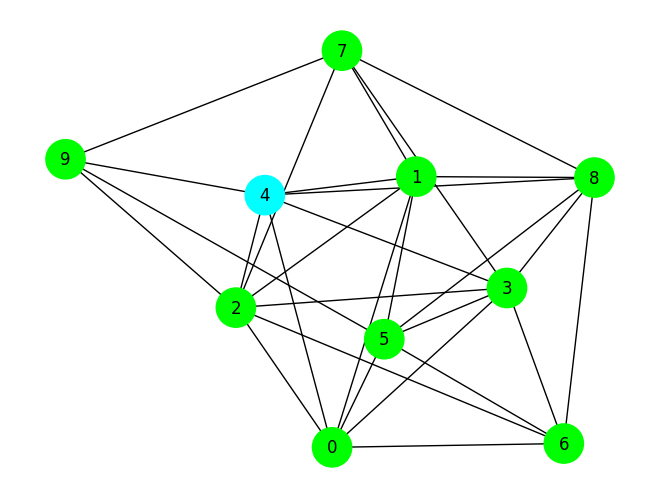

In [93]:
nx.draw(G1,
        with_labels=True,
        node_color = node_color,
        node_size=800)

In [94]:
infection_times = nx.get_node_attributes(G1, "inf_time")

infection_times

{0: 1, 1: 4, 2: 3, 3: 2, 4: inf, 5: 2, 6: 2, 7: 4, 8: 3, 9: 3}

Drawing graph with the infection times for each node (inf means the node has never been infected)

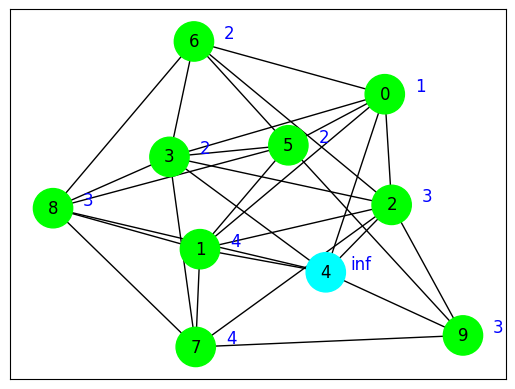

In [95]:
pos = nx.spring_layout(G1, seed = 0)
state_pos = {n: (x + 0.14, y + 0.05) for n, (x,y) in pos.items()}

nx.draw_networkx(G1,
                 pos,
                 node_size = 800,
                 node_color = node_color,)

nx.draw_networkx_labels(G1, state_pos, labels= infection_times, font_color='blue')
plt.show()

Deleting nodes that we known were not infected from the graph.

In [200]:
node_statuses = nx.get_node_attributes(G1, "status")
removable_indices = [i for i, x in node_statuses.items() if x == 'susceptible']
print(removable_indices)

[4]


In [201]:
for node in removable_indices:
  G1.remove_node(node)

Selecting a fraction of nodes that will not be observed.

Notice that if we have informations on some nodes that where never infected we can just remove them from the graph.

In [202]:
def excludeInfTime(G, p):
    N = round(p*len(G.nodes))

    #We remove the node 0 from the possible removed nodes.
    excluded_nodes = np.random.choice(list(G.nodes)[1:], N, replace = False)

    for node in excluded_nodes:
        G.nodes[node]['inf_time'] = math.inf
        G.nodes[node]['status'] = ''

    obs_infected_nodes = [k for k,v in nx.get_node_attributes(G, 'status').items() if v.startswith('r')]


    return excluded_nodes, obs_infected_nodes

In [203]:
p_excluded = 0.4
excluded, infected_nodes = excludeInfTime(G1, p_excluded)

In [204]:
infected_nodes

[0, 2, 7]

In [205]:
for node in G1.nodes:
    print(G1.nodes[node])

{'status': 'recovered', 'inf_time': 1}
{'status': '', 'inf_time': inf}
{'status': 'recovered', 'inf_time': 3}
{'status': '', 'inf_time': inf}
{'status': '', 'inf_time': inf}
{'status': '', 'inf_time': 1}
{'status': 'recovered', 'inf_time': 4}
{'status': '', 'inf_time': inf}
{'status': '', 'inf_time': inf}


#### Depth-First-Search (DFS) with Infection Time Constraints

Input: Graph *G*, start node *v*, target node *t*, path length *k*, current path *path*, visited nodes *visited*.

Output: Returns a path if the target *t* is reached and the path length is exactly *k*, otherwise returns **None**.

In [206]:
def DFS_random(G, v, t,k, path, visited):

    #If the current node is the target node and the length of the path - 1 is k, we have found
    #desired path
    if v == t and len(path) - 1 == k:
        return path

    if len(path) - 1 > k:
        return None

    #If the target node is reached before the length of the desired path, then no path is returned
    if len(path) - 1 < k + 1 and v == t:
        return None

    #In this case, we have found an observed node in the middle of the path
    #while searching for a v-t path whose infection time relates to the current path size
    if len(path) > 1 and (k -  G.nodes[v]['inf_time'] == len(path) - 1):
        return path

    #We have found an observed node that does not relate to the current path size
    if G.nodes[v]['inf_time'] != math.inf and (k - G.nodes[v]['inf_time'] != len(path) - 1):
        return None

    #Each unobserved node we pass in the path receives a infection time
    G.nodes[v]['inf_time'] = k - len(path) + 1
    visited[v] = True

    aux_neighbors  = list(G.neighbors(v))
    rd.shuffle(aux_neighbors) #rd.shuffle is an in-place function

    for neighbor in aux_neighbors:
        if not visited[neighbor]:
            result = DFS_random(G, neighbor, t, k, path + [neighbor], visited)
            #If a desired path is returned we return it
            if result:
                return result

    #The two lines above deals with the process of backtracking in the search
    visited[v] = False
    G.nodes[v]['inf_time'] = math.inf

In [207]:
#INPUT: A graph G, an integer s that refers to the initial node on the path,
#an integer that is the target node and an integer k that refers to the length of the desired path.
def find_k_length_path(G, s, t, k):
    visited = {}
    for node in G.nodes:
        visited[node] = False
    return DFS_random(G, s, t, k, [s], visited)

Now we use the functions above to find a feasible tree for the observed data.

In [208]:
def feasible_tree(G, infected_nodes):
    tree = []
    for node in infected_nodes:
        tree_aux = find_k_length_path(G, node, 0, G.nodes[node]['inf_time'])
        tree.append(tree_aux)
    return tree

Testing with the above example:

In [209]:
T_initial = feasible_tree(G1, infected_nodes)
T_initial

[None, [2, 9, 5, 0], [7, 8, 1, 5]]

In [210]:
for node in G1.nodes:
    print(G1.nodes[node])

{'status': 'recovered', 'inf_time': 1}
{'status': '', 'inf_time': 2}
{'status': 'recovered', 'inf_time': 3}
{'status': '', 'inf_time': inf}
{'status': '', 'inf_time': 1}
{'status': '', 'inf_time': 1}
{'status': 'recovered', 'inf_time': 4}
{'status': '', 'inf_time': 3}
{'status': '', 'inf_time': 2}


### Samplings

We begin with an initial version. We have a initial tree. We take a random node in the observed list, for example $v$, and choose anothe path from $v$. The new tree is always acepted and then the process is repeated.

When the loop runs for the second time, we modify T_initial again. and all previous entries in sampling (which are just references to T_initial) will change to the latest, final state of T_initial. This is why we need a deep copy of each T_initial.

In [223]:
def sampling_trees(G,T_initial,n, infected_nodes):
  sampling = [T_initial]

  for i in range(n):
    T_current = sampling[i]
    _
    random_node_aux = rd.randrange(1, len(infected_nodes)) #Excludes the node 0, since it's the root of the tree
    random_node = infected_nodes[random_node_aux]

    #Delete the previous path from G
    #Recall that all nodes in T_current[random_node_aux][1:-1] are unobserved nodes
    for node in T_current[random_node_aux][1:-1]:
      G.nodes[node]['inf_time'] = math.inf

    #Find a new path for
    new_path = find_k_length_path(G, random_node, 0, G.nodes[random_node]['inf_time'])

    # Modify the current state
    T_current[random_node_aux] = new_path

    # Append a unique copy of the current state to the sampling list
    sampling.append(copy.deepcopy(T_current))

  return sampling

Testing with the example:

In [224]:
samplings_number = 10
samplings = sampling_trees(G1, T_initial, samplings_number, infected_nodes)
samplings

[[None, [2, 9, 5, 0], [7, 9, 5, 1, 0]],
 [None, [2, 9, 5, 0], [7, 1, 5, 3, 0]],
 [None, [2, 6], [7, 1, 5, 3, 0]],
 [None, [2, 6], [7, 8]],
 [None, [2, 9, 5, 0], [7, 8]],
 [None, [2, 6], [7, 8]],
 [None, [2, 9, 5, 0], [7, 8]],
 [None, [2, 1, 5, 0], [7, 8]],
 [None, [2, 6], [7, 8]],
 [None, [2, 6], [7, 8]],
 [None, [2, 6], [7, 8]]]

  Counts the proportions of appearence of each node.

  obs: The any() function in Python is a built-in function that takes an iterable as input and returns True if at least one element in the iterable is considered True. In this case returns True if the element is found.



In [248]:
nodes_prop = {x: 0 for x in list(G1.nodes)}
for node in G1.nodes:
  for lis in samplings:
    is_present = any(node in sublist for sublist in lis[1:])
    nodes_prop[node] += is_present

for node in nodes_prop:
  nodes_prop[node] = nodes_prop[node]/(samplings_number + 1)

In [249]:
nodes_prop

{0: 0.5454545454545454,
 1: 0.36363636363636365,
 2: 1.0,
 3: 0.18181818181818182,
 5: 0.5454545454545454,
 6: 0.5454545454545454,
 7: 1.0,
 8: 0.7272727272727273,
 9: 0.36363636363636365}